# 02 — Billing Analysis

Explores the output of `src/billing/billing_engine.py`: expected vs. billed
revenue per merchant-month, and the resulting billing_status classification.
See `docs/kpi_definitions.md` for the Billing Accuracy formula and
`src/billing/billing_engine.py`'s docstring for the classification logic.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
RAW = ROOT / "data" / "raw"
PROCESSED = ROOT / "data" / "processed"

plt.rcParams["figure.figsize"] = (9, 4.5)
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False
COLOR_PRIMARY = "#2A5CA6"
COLOR_RISK = "#C0392B"
COLOR_WARN = "#D68910"
COLOR_OK = "#2E8B57"
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")


In [2]:
billing = pd.read_csv(PROCESSED / "billing_analysis.csv")
merchants = pd.read_csv(PROCESSED / "merchants.csv")[["merchant_id", "merchant_segment"]]
billing = billing.merge(merchants, on="merchant_id", how="left")
billing.head()

,merchant_id,billing_period,invoice_id,expected_revenue,actual_billed_revenue,revenue_difference,variance_percent,billing_status,merchant_segment
0,MER00001,2024-08,INV0000001,341.52,341.52,0.00,0.00,Correct,SMB
1,MER00001,2024-09,INV0000002,367.31,367.31,0.00,0.00,Correct,SMB
2,MER00001,2024-10,INV0000003,250.74,250.74,0.00,0.00,Correct,SMB
3,MER00001,2024-11,INV0000004,457.41,457.41,0.00,0.00,Correct,SMB
4,MER00001,2024-12,INV0000005,263.67,263.67,0.00,0.00,Correct,SMB


## Billing status breakdown

Billing accuracy: 89.37% (18,357 of 20,540 merchant-months)


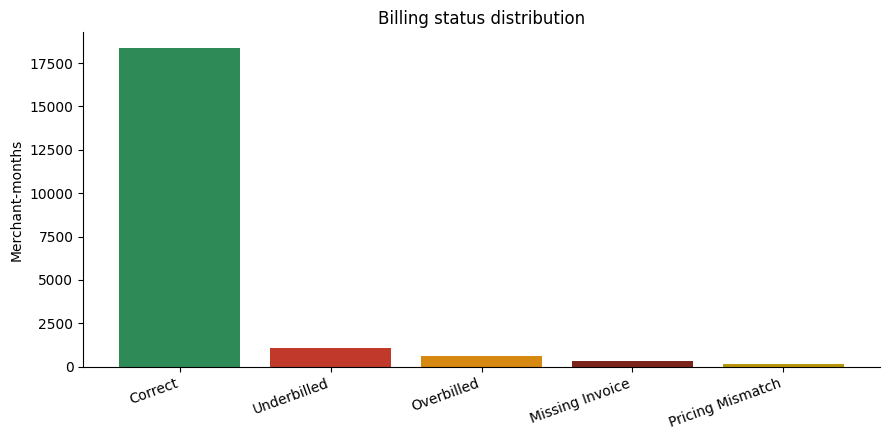

In [3]:
status_counts = billing["billing_status"].value_counts()
accuracy_pct = round(100 * status_counts.get("Correct", 0) / status_counts.sum(), 2)
print(f"Billing accuracy: {accuracy_pct}% ({status_counts.get('Correct', 0):,} of {status_counts.sum():,} merchant-months)")

fig, ax = plt.subplots()
colors = {"Correct": COLOR_OK, "Underbilled": COLOR_RISK, "Overbilled": COLOR_WARN,
          "Missing Invoice": "#7B241C", "Pricing Mismatch": "#B7950B"}
ax.bar(status_counts.index, status_counts.values, color=[colors.get(s, COLOR_PRIMARY) for s in status_counts.index])
ax.set_ylabel("Merchant-months")
ax.set_title("Billing status distribution")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

## Expected vs. billed revenue, monthly trend

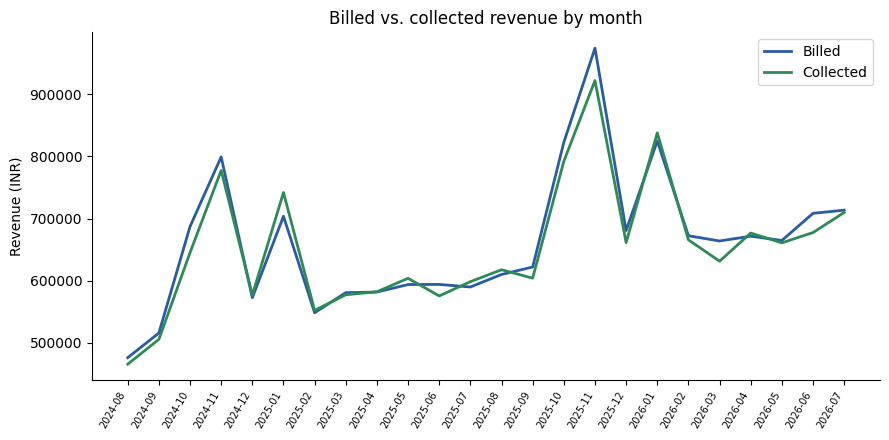

In [4]:
realization_month = pd.read_csv(PROCESSED / "revenue_realization_by_month.csv")
fig, ax = plt.subplots()
ax.plot(realization_month["billing_period"], realization_month["billed_revenue"], label="Billed", color=COLOR_PRIMARY, linewidth=2)
ax.plot(realization_month["billing_period"], realization_month["collected_revenue"], label="Collected", color=COLOR_OK, linewidth=2)
ax.set_ylabel("Revenue (INR)")
ax.set_title("Billed vs. collected revenue by month")
ax.legend()
plt.xticks(rotation=60, ha="right", fontsize=7)
plt.tight_layout()
plt.show()

## Billing errors by merchant segment

In [5]:
errors = billing[billing["billing_status"] != "Correct"]
seg_errors = errors.groupby(["merchant_segment", "billing_status"]).size().unstack(fill_value=0)
seg_errors

billing_status,Missing Invoice,Overbilled,Pricing Mismatch,Underbilled
merchant_segment,,,,
Enterprise,20,35,4,37
Long-tail,124,247,66,473
Mid-Market,57,77,28,137
SMB,139,252,58,429


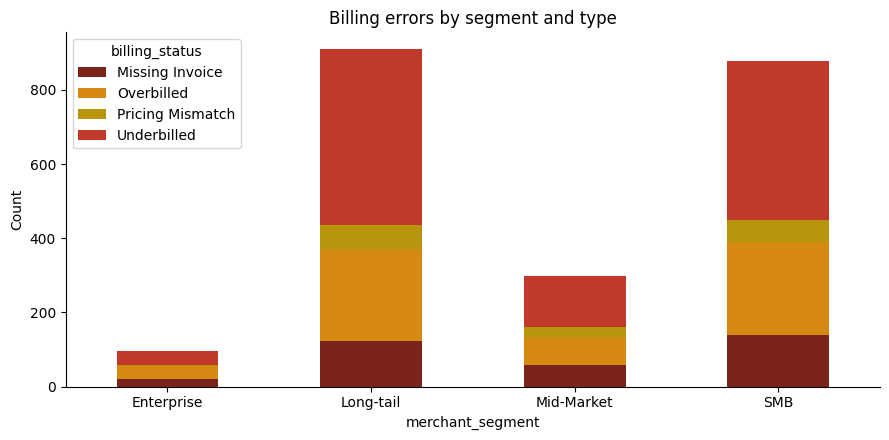

In [6]:
fig, ax = plt.subplots()
seg_errors.plot(kind="bar", stacked=True, ax=ax,
                 color=[colors.get(c, COLOR_PRIMARY) for c in seg_errors.columns])
ax.set_ylabel("Count")
ax.set_title("Billing errors by segment and type")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## Merchants with the most recurring billing errors

In [7]:
repeat_offenders = errors.groupby("merchant_id").size().sort_values(ascending=False).head(10)
repeat_offenders.to_frame("error_count")

,error_count
merchant_id,
MER00934,8
MER00095,7
MER00250,7
MER00591,7
MER00506,7
MER00248,7
MER00669,7
MER00406,6
MER00457,6


## Takeaways

- Billing accuracy sits around 91% — see `docs/business_insights.md` insight
  #3 for the split between high-frequency/low-severity Underbilling and
  low-frequency/high-severity Missing Invoice.
- A small set of merchants accounts for a disproportionate share of repeat
  billing errors — a merchant-specific contract/config audit is cheaper
  than continuing to catch the same error every cycle (insight #9).